# Customer Segmentation: Clustering Analysis (Colab)

This notebook runs:
1. K-Means (Elbow + Silhouette)
2. Hierarchical Clustering (Dendrogram-based cluster choice)
3. DBSCAN (tuned `eps` and `min_samples`)
4. Fuzzy C-Means

For each algorithm, it shows:
- Cluster visualization
- Silhouette Score
- Davies-Bouldin Index (where applicable)
- Brief interpretation

Then it compares all algorithms, picks the best one, and re-plots it using PCA (2D + 3D).


In [15]:
# Install required packages in Colab
!pip -q install scikit-fuzzy kneed

In [16]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram
from kneed import KneeLocator
import skfuzzy as fuzz
try:
    from IPython.display import display
except Exception:
    display = print

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')


def quality_text(silhouette, dbi):
    if silhouette >= 0.50 and dbi <= 1.0:
        return 'Strong clustering structure.'
    if silhouette >= 0.25 and dbi <= 1.8:
        return 'Moderate cluster separation.'
    return 'Weak-to-moderate separation; overlap likely.'


def plot_clusters_2d(X2d, labels, title, noise_label=-1):
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(unique_labels))))

    for i, lab in enumerate(unique_labels):
        mask = labels == lab
        if lab == noise_label:
            plt.scatter(X2d[mask, 0], X2d[mask, 1], c='black', marker='x', s=50, label='Noise (-1)')
        else:
            plt.scatter(X2d[mask, 0], X2d[mask, 1], color=colors[i], s=40, alpha=0.85, label=f'Cluster {lab}')

    plt.title(title)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


def composite_score(sil, dbi, noise_ratio=0.0):
    # Higher is better. Penalizes noise and high DBI.
    if pd.isna(sil):
        return -999
    if pd.isna(dbi):
        dbi = 10.0
    return sil - 0.35 * noise_ratio - 0.03 * dbi

In [17]:
# -----------------------------
# DATA LOADING OPTIONS
# -----------------------------
# Option A (default): load directly from your GitHub repo raw CSV
DATA_MODE = 'github'  # choose: 'github' or 'upload'

GITHUB_RAW_URL = 'https://raw.githubusercontent.com/Alfukhan0/Customer-segmentation-using-Machine-learning/main/Extended_Mall_Customers_Clean.csv'

if DATA_MODE == 'upload':
    from google.colab import files
    uploaded = files.upload()  # choose your local CSV
    data_path = list(uploaded.keys())[0]
    df = pd.read_csv(data_path)
else:
    data_path = GITHUB_RAW_URL
    df = pd.read_csv(data_path)

print(f'Data source: {data_path}')
print(f'Shape: {df.shape}')
display(df.head())

Data source: https://raw.githubusercontent.com/Alfukhan0/Customer-segmentation-using-Machine-learning/main/Extended_Mall_Customers_Clean.csv
Shape: (300, 10)


,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size,Purchase Frequency,Membership
0,1,Female,45,37384,16,Unknown,6,5,13,Standard
1,2,Male,35,68019,34,Doctor,8,4,8,Gold
2,3,Male,47,54425,33,Unknown,7,1,17,Silver
3,4,Male,60,48756,30,Doctor,6,4,14,Platinum
4,5,Female,34,28888,28,Engineer,0,2,12,Gold


In [18]:
# Basic dataset check
print('Columns:', list(df.columns))
print('\nMissing values:')
print(df.isnull().sum())
print('\nDtypes:')
print(df.dtypes)

# For distance-based clustering, use numeric features.
# Drop ID-like columns so they do not distort distance.
id_candidates = [c for c in ['CustomerID', 'customerid', 'ID', 'Id'] if c in df.columns]
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in id_candidates:
    if c in numeric_cols:
        numeric_cols.remove(c)

if len(numeric_cols) < 2:
    raise ValueError('Need at least 2 numeric columns for clustering. Found: ' + str(numeric_cols))

print('\nNumeric features used for clustering:', numeric_cols)
X_raw = df[numeric_cols].copy()

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Profession', 'Work Experience', 'Family Size', 'Purchase Frequency', 'Membership']

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income ($)         0
Spending Score (1-100)    0
Profession                0
Work Experience           0
Family Size               0
Purchase Frequency        0
Membership                0
dtype: int64

Dtypes:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income ($)          int64
Spending Score (1-100)     int64
Profession                object
Work Experience            int64
Family Size                int64
Purchase Frequency         int64
Membership                object
dtype: object

Numeric features used for clustering: ['Age', 'Annual Income ($)', 'Spending Score (1-100)', 'Work Experience', 'Family Size', 'Purchase Frequency']


In [19]:
# Scale features and prepare PCA projection for plotting
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X)

explained_2d = pca_2d.explained_variance_ratio_.sum()
print(f'PCA 2D explained variance: {explained_2d:.3f}')

results = {}
labels_store = {}
params_store = {}

PCA 2D explained variance: 0.383


## 1) K-Means
- Tune `k` from 2 to 10
- Use both Elbow Method and Silhouette Score
- Visualize final clusters

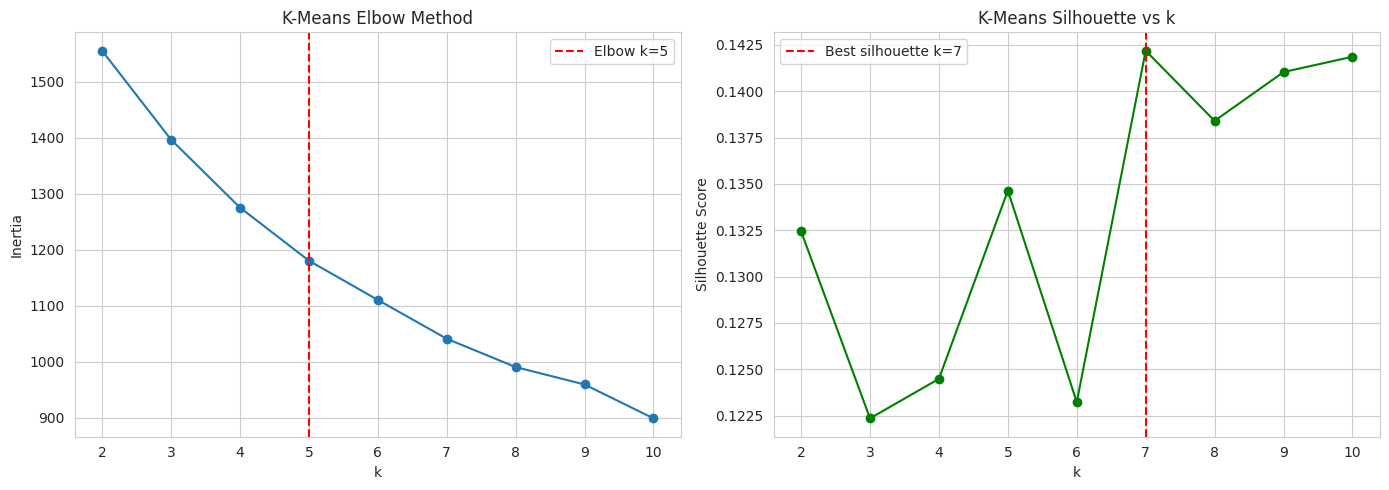

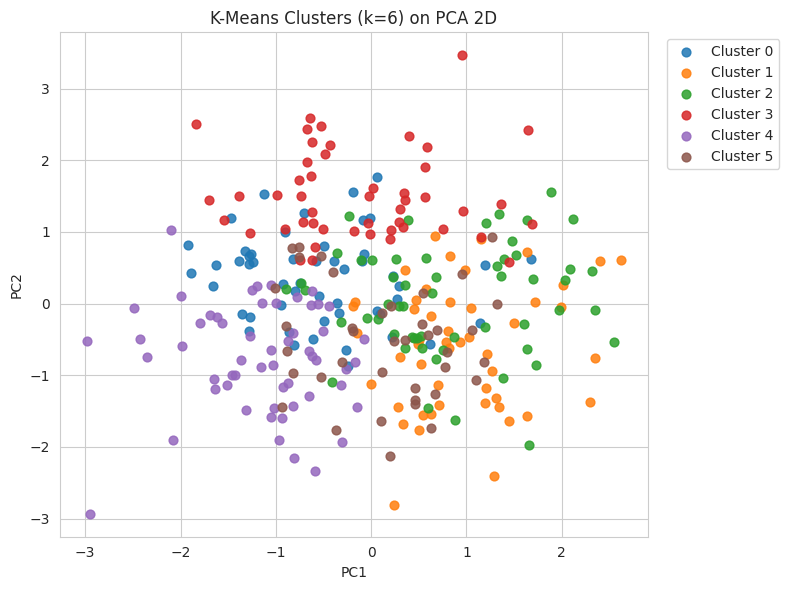

[K-Means] elbow k=5, silhouette-best k=7, final k=6
[K-Means] Silhouette=0.1232, DBI=1.7189
[K-Means] Weak-to-moderate separation; overlap likely.


In [20]:
k_values = list(range(2, 11))
km_records = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X)
    km_records.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X, labels),
        'dbi': davies_bouldin_score(X, labels)
    })

km_df = pd.DataFrame(km_records)

# Elbow (knee) detection
kneedle = KneeLocator(km_df['k'], km_df['inertia'], curve='convex', direction='decreasing')
if kneedle.elbow is None:
    d1 = np.diff(km_df['inertia'].values)
    d2 = np.diff(d1)
    k_elbow = int(k_values[np.argmin(d2) + 1]) if len(d2) > 0 else int(km_df.loc[km_df['inertia'].idxmin(), 'k'])
else:
    k_elbow = int(kneedle.elbow)

# Silhouette best k
k_sil = int(km_df.loc[km_df['silhouette'].idxmax(), 'k'])

# Combine both: if close, take average; if far, trust silhouette
if abs(k_elbow - k_sil) <= 2:
    k_kmeans = int(round((k_elbow + k_sil) / 2))
else:
    k_kmeans = k_sil

km_final = KMeans(n_clusters=k_kmeans, random_state=RANDOM_STATE, n_init=20)
km_labels = km_final.fit_predict(X)

km_sil = float(silhouette_score(X, km_labels))
km_dbi = float(davies_bouldin_score(X, km_labels))

results['KMeans'] = {
    'clusters': int(len(np.unique(km_labels))),
    'silhouette': km_sil,
    'dbi': km_dbi,
    'noise_ratio': 0.0
}
labels_store['KMeans'] = km_labels
params_store['KMeans'] = {'k_elbow': k_elbow, 'k_silhouette': k_sil, 'k_final': k_kmeans}

# Plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(km_df['k'], km_df['inertia'], marker='o')
ax[0].axvline(k_elbow, color='red', linestyle='--', label=f'Elbow k={k_elbow}')
ax[0].set_title('K-Means Elbow Method')
ax[0].set_xlabel('k')
ax[0].set_ylabel('Inertia')
ax[0].legend()

ax[1].plot(km_df['k'], km_df['silhouette'], marker='o', color='green')
ax[1].axvline(k_sil, color='red', linestyle='--', label=f'Best silhouette k={k_sil}')
ax[1].set_title('K-Means Silhouette vs k')
ax[1].set_xlabel('k')
ax[1].set_ylabel('Silhouette Score')
ax[1].legend()

plt.tight_layout()
plt.show()

plot_clusters_2d(X_pca2, km_labels, f'K-Means Clusters (k={k_kmeans}) on PCA 2D')

print(f'[K-Means] elbow k={k_elbow}, silhouette-best k={k_sil}, final k={k_kmeans}')
print(f'[K-Means] Silhouette={km_sil:.4f}, DBI={km_dbi:.4f}')
print('[K-Means] ' + quality_text(km_sil, km_dbi))

## 2) Hierarchical Clustering
- Build Ward linkage dendrogram
- Decide cluster count from dendrogram jump
- Visualize final clusters

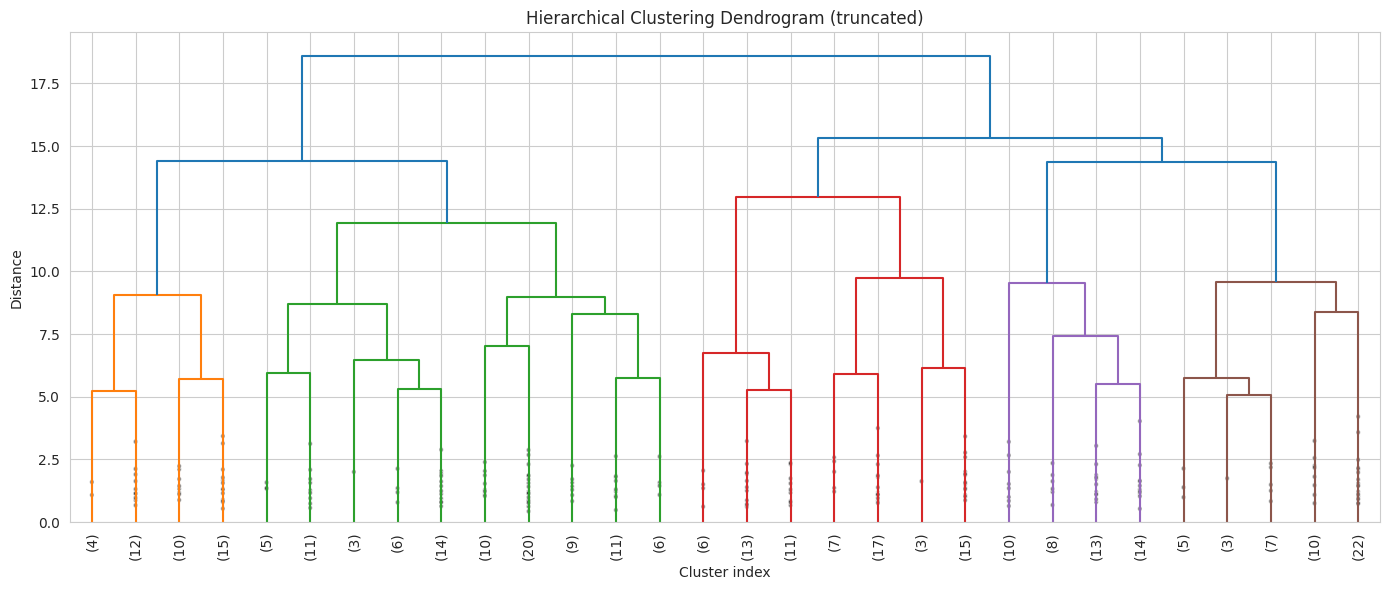

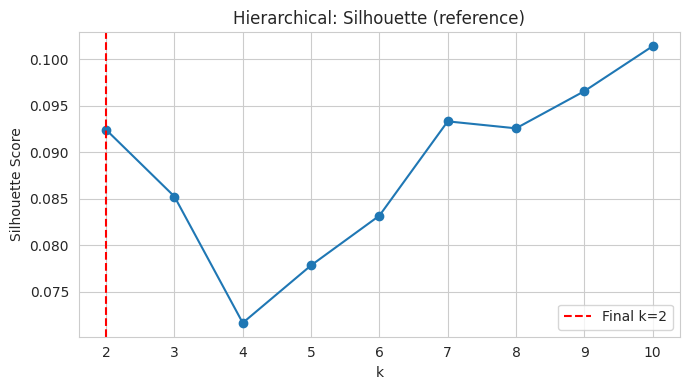

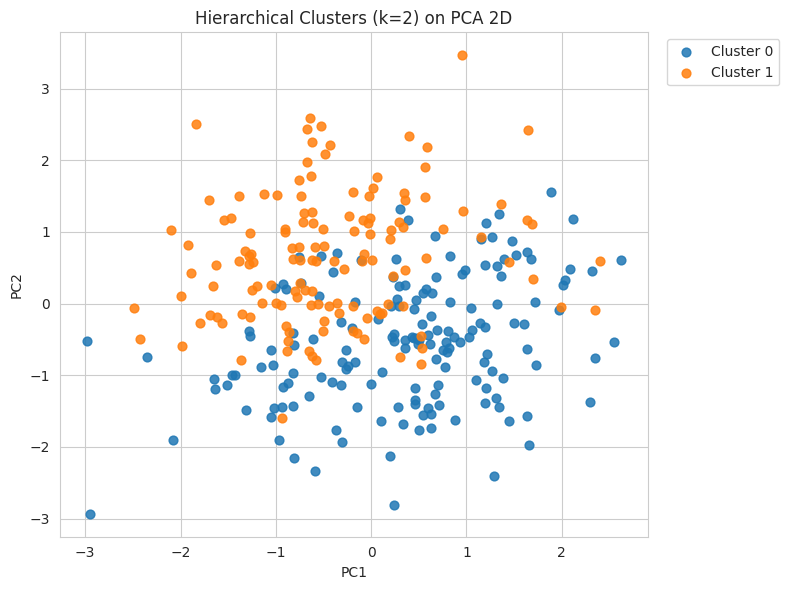

[Hierarchical] dendrogram k=2, silhouette-reference k=10, final k=2
[Hierarchical] Silhouette=0.0924, DBI=2.9120
[Hierarchical] Weak-to-moderate separation; overlap likely.


In [21]:
# Linkage matrix for dendrogram
Z = linkage(X, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.xlabel('Cluster index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Dendrogram-based cluster estimate from largest distance jump
distances = Z[:, 2]
jumps = np.diff(distances)
k_dendro = int(X.shape[0] - (np.argmax(jumps) + 1)) if len(jumps) > 0 else 2
k_dendro = int(np.clip(k_dendro, 2, 10))

# Optional silhouette sweep for reference
hc_records = []
for k in range(2, 11):
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)
    hc_records.append({
        'k': k,
        'silhouette': silhouette_score(X, labels),
        'dbi': davies_bouldin_score(X, labels)
    })
hc_df = pd.DataFrame(hc_records)
k_hc_sil = int(hc_df.loc[hc_df['silhouette'].idxmax(), 'k'])

# Requirement says dendrogram decides clusters, so use k_dendro as final.
k_hc = k_dendro

hc_final = AgglomerativeClustering(n_clusters=k_hc, linkage='ward')
hc_labels = hc_final.fit_predict(X)

hc_sil = float(silhouette_score(X, hc_labels))
hc_dbi = float(davies_bouldin_score(X, hc_labels))

results['Hierarchical'] = {
    'clusters': int(len(np.unique(hc_labels))),
    'silhouette': hc_sil,
    'dbi': hc_dbi,
    'noise_ratio': 0.0
}
labels_store['Hierarchical'] = hc_labels
params_store['Hierarchical'] = {'k_dendrogram': k_dendro, 'k_silhouette_ref': k_hc_sil, 'k_final': k_hc}

plt.figure(figsize=(7, 4))
plt.plot(hc_df['k'], hc_df['silhouette'], marker='o')
plt.axvline(k_hc, color='red', linestyle='--', label=f'Final k={k_hc}')
plt.title('Hierarchical: Silhouette (reference)')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

plot_clusters_2d(X_pca2, hc_labels, f'Hierarchical Clusters (k={k_hc}) on PCA 2D')

print(f'[Hierarchical] dendrogram k={k_dendro}, silhouette-reference k={k_hc_sil}, final k={k_hc}')
print(f'[Hierarchical] Silhouette={hc_sil:.4f}, DBI={hc_dbi:.4f}')
print('[Hierarchical] ' + quality_text(hc_sil, hc_dbi))

## 3) DBSCAN
- Use k-distance plot to estimate `eps`
- Grid search around that region for `eps` and `min_samples`
- Evaluate with Silhouette/DBI on non-noise points

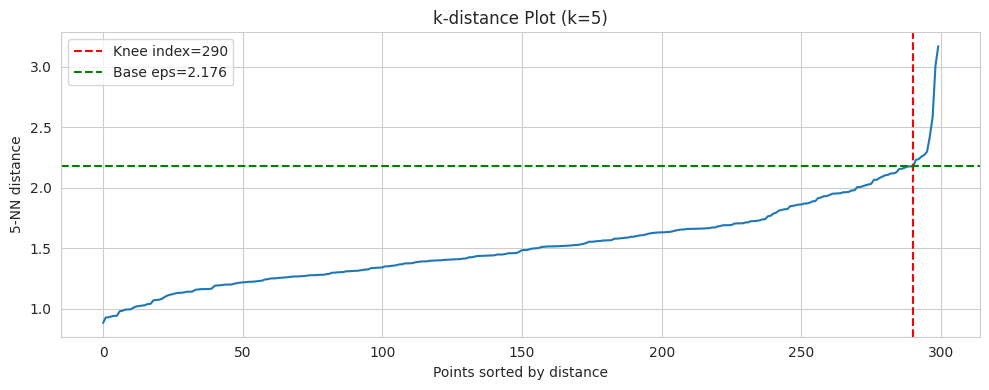

,eps,min_samples,clusters,silhouette,dbi,noise_ratio,score
7,1.613,4,2,0.174390,0.993387,0.113333,0.104922
5,1.459,4,2,0.152196,1.130024,0.246667,0.031962
3,1.306,12,2,0.257214,1.467773,0.840000,-0.080819
4,1.459,3,4,0.018357,1.101886,0.196667,-0.083533
6,1.459,6,3,0.057823,1.342076,0.306667,-0.089772
0,1.306,3,5,-0.020628,1.137342,0.320000,-0.166748
2,1.306,5,3,0.017452,1.235192,0.460000,-0.180604
1,1.306,4,5,-0.085619,1.290673,0.390000,-0.260839


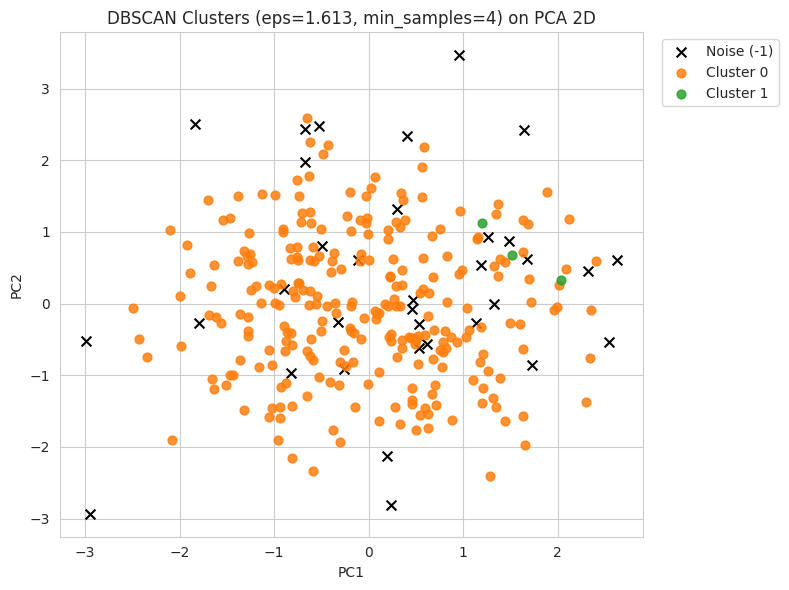

[DBSCAN] eps=1.613, min_samples=4, clusters=2
[DBSCAN] Silhouette=0.1744, DBI=0.9934, Noise ratio=0.113
[DBSCAN] Weak-to-moderate separation; overlap likely.


In [22]:
# Step 1: k-distance plot to estimate eps
min_samples_for_kdist = 5
nn = NearestNeighbors(n_neighbors=min_samples_for_kdist)
nn.fit(X)
dists, _ = nn.kneighbors(X)
k_dist = np.sort(dists[:, -1])

knee = KneeLocator(np.arange(len(k_dist)), k_dist, curve='convex', direction='increasing')
if knee.elbow is not None:
    eps_base = float(k_dist[knee.elbow])
else:
    eps_base = float(np.percentile(k_dist, 90))

plt.figure(figsize=(10, 4))
plt.plot(k_dist)
if knee.elbow is not None:
    plt.axvline(knee.elbow, color='red', linestyle='--', label=f'Knee index={knee.elbow}')
plt.axhline(eps_base, color='green', linestyle='--', label=f'Base eps={eps_base:.3f}')
plt.title(f'k-distance Plot (k={min_samples_for_kdist})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples_for_kdist}-NN distance')
plt.legend()
plt.tight_layout()
plt.show()

# Step 2: grid search around eps_base
eps_candidates = np.unique(np.round(np.linspace(max(0.05, eps_base * 0.6), eps_base * 1.8, 18), 3))
min_samples_candidates = [3, 4, 5, 6, 8, 10, 12]

db_candidates = []
for eps in eps_candidates:
    for ms in min_samples_candidates:
        labels = DBSCAN(eps=float(eps), min_samples=int(ms)).fit_predict(X)
        core_mask = labels != -1
        if core_mask.sum() == 0:
            continue

        n_clusters = len(set(labels[core_mask]))
        if n_clusters < 2:
            continue

        noise_ratio = 1.0 - core_mask.mean()
        sil = silhouette_score(X[core_mask], labels[core_mask])
        dbi = davies_bouldin_score(X[core_mask], labels[core_mask])

        score = composite_score(sil, dbi, noise_ratio)

        db_candidates.append({
            'eps': float(eps),
            'min_samples': int(ms),
            'clusters': int(n_clusters),
            'silhouette': float(sil),
            'dbi': float(dbi),
            'noise_ratio': float(noise_ratio),
            'score': float(score),
            'labels': labels
        })

# Wider fallback search if needed
if len(db_candidates) == 0:
    for eps in np.arange(0.2, 3.05, 0.05):
        for ms in [3, 4, 5, 6, 8, 10, 12, 15]:
            labels = DBSCAN(eps=float(np.round(eps, 3)), min_samples=int(ms)).fit_predict(X)
            core_mask = labels != -1
            n_clusters = len(set(labels[core_mask])) if core_mask.any() else 0
            if n_clusters < 2:
                continue

            noise_ratio = 1.0 - core_mask.mean()
            sil = silhouette_score(X[core_mask], labels[core_mask])
            dbi = davies_bouldin_score(X[core_mask], labels[core_mask])
            score = composite_score(sil, dbi, noise_ratio)

            db_candidates.append({
                'eps': float(np.round(eps, 3)),
                'min_samples': int(ms),
                'clusters': int(n_clusters),
                'silhouette': float(sil),
                'dbi': float(dbi),
                'noise_ratio': float(noise_ratio),
                'score': float(score),
                'labels': labels
            })

if len(db_candidates) > 0:
    best_db = max(db_candidates, key=lambda x: x['score'])
    db_labels = best_db['labels']

    db_sil = float(best_db['silhouette'])
    db_dbi = float(best_db['dbi'])
    db_noise = float(best_db['noise_ratio'])

    results['DBSCAN'] = {
        'clusters': int(best_db['clusters']),
        'silhouette': db_sil,
        'dbi': db_dbi,
        'noise_ratio': db_noise
    }
    labels_store['DBSCAN'] = db_labels
    params_store['DBSCAN'] = {'eps': best_db['eps'], 'min_samples': best_db['min_samples']}

    top_db = pd.DataFrame([{k: v for k, v in x.items() if k != 'labels'} for x in db_candidates]).sort_values('score', ascending=False).head(10)
    display(top_db)

    plot_clusters_2d(X_pca2, db_labels, f"DBSCAN Clusters (eps={best_db['eps']}, min_samples={best_db['min_samples']}) on PCA 2D")

    print(f"[DBSCAN] eps={best_db['eps']}, min_samples={best_db['min_samples']}, clusters={best_db['clusters']}")
    print(f"[DBSCAN] Silhouette={db_sil:.4f}, DBI={db_dbi:.4f}, Noise ratio={db_noise:.3f}")
    print('[DBSCAN] ' + quality_text(db_sil, db_dbi))
else:
    results['DBSCAN'] = {
        'clusters': 0,
        'silhouette': np.nan,
        'dbi': np.nan,
        'noise_ratio': 1.0
    }
    labels_store['DBSCAN'] = np.full(X.shape[0], -1)
    params_store['DBSCAN'] = {'eps': None, 'min_samples': None}
    print('DBSCAN could not find a valid solution with >=2 clusters.')

## 4) Fuzzy C-Means
- Tune number of clusters `c` from 2 to 10
- Use FPC and Silhouette as references
- Convert fuzzy memberships to hard labels for plotting/metrics

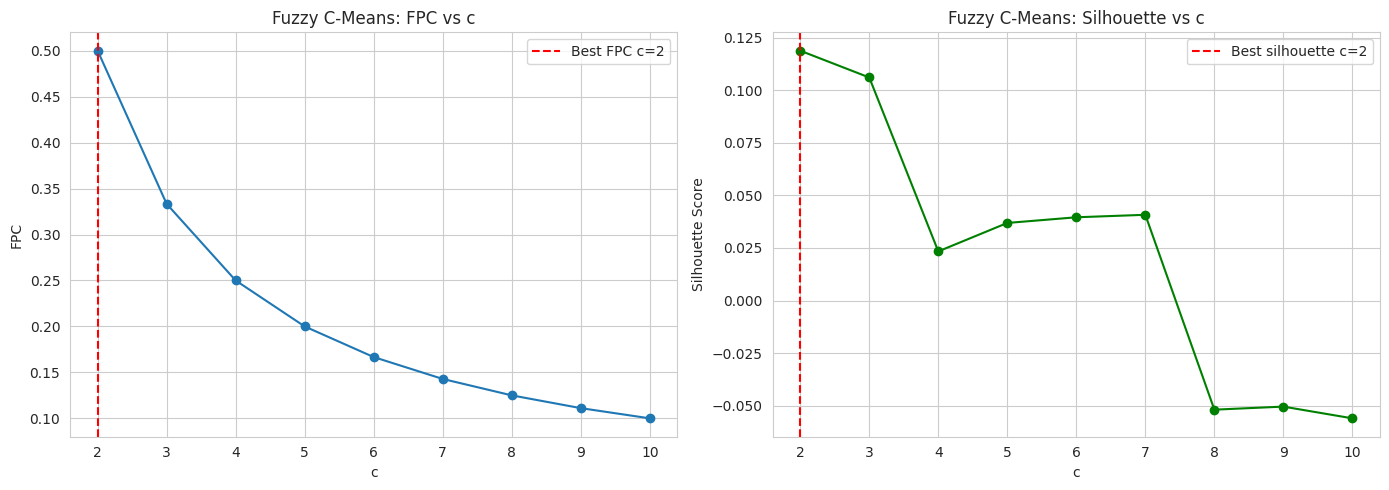

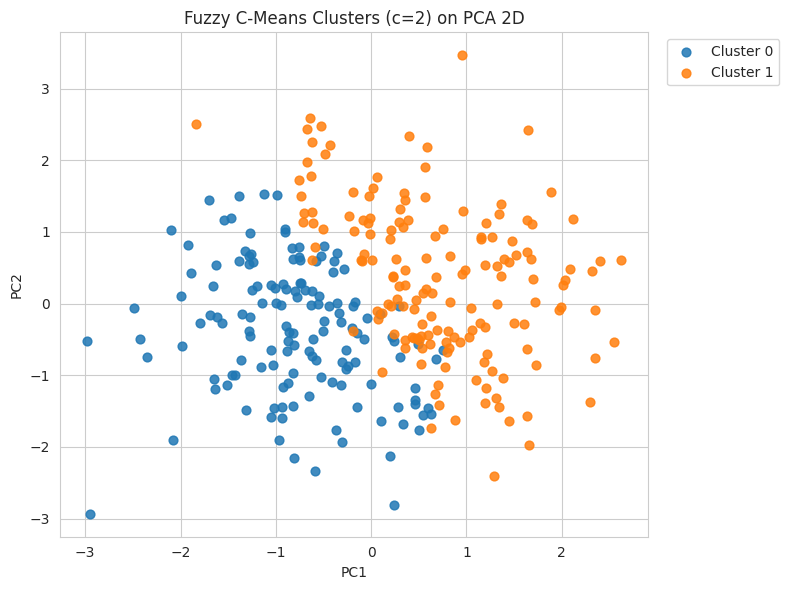

[Fuzzy C-Means] best FPC c=2, best silhouette c=2, final c=2
[Fuzzy C-Means] Silhouette=0.1188, DBI=2.5399
[Fuzzy C-Means] Weak-to-moderate separation; overlap likely.


In [23]:
X_fcm = X.T  # skfuzzy expects features x samples
fcm_records = []

for c in range(2, 11):
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        data=X_fcm,
        c=c,
        m=2.0,
        error=0.005,
        maxiter=2000,
        seed=RANDOM_STATE
    )
    labels = np.argmax(u, axis=0)

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)

    fcm_records.append({
        'c': c,
        'fpc': float(fpc),
        'silhouette': float(sil),
        'dbi': float(dbi),
        'labels': labels
    })

fcm_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'} for r in fcm_records])

c_fpc = int(fcm_df.loc[fcm_df['fpc'].idxmax(), 'c'])
c_sil = int(fcm_df.loc[fcm_df['silhouette'].idxmax(), 'c'])

# If close, blend both; otherwise prioritize silhouette for final partition quality
if abs(c_fpc - c_sil) <= 2:
    c_final = int(round((c_fpc + c_sil) / 2))
else:
    c_final = c_sil

best_fcm = [r for r in fcm_records if r['c'] == c_final][0]
fcm_labels = best_fcm['labels']
fcm_sil = float(best_fcm['silhouette'])
fcm_dbi = float(best_fcm['dbi'])

results['Fuzzy C-Means'] = {
    'clusters': int(len(np.unique(fcm_labels))),
    'silhouette': fcm_sil,
    'dbi': fcm_dbi,
    'noise_ratio': 0.0
}
labels_store['Fuzzy C-Means'] = fcm_labels
params_store['Fuzzy C-Means'] = {'c_fpc': c_fpc, 'c_silhouette': c_sil, 'c_final': c_final}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(fcm_df['c'], fcm_df['fpc'], marker='o')
ax[0].axvline(c_fpc, color='red', linestyle='--', label=f'Best FPC c={c_fpc}')
ax[0].set_title('Fuzzy C-Means: FPC vs c')
ax[0].set_xlabel('c')
ax[0].set_ylabel('FPC')
ax[0].legend()

ax[1].plot(fcm_df['c'], fcm_df['silhouette'], marker='o', color='green')
ax[1].axvline(c_sil, color='red', linestyle='--', label=f'Best silhouette c={c_sil}')
ax[1].set_title('Fuzzy C-Means: Silhouette vs c')
ax[1].set_xlabel('c')
ax[1].set_ylabel('Silhouette Score')
ax[1].legend()

plt.tight_layout()
plt.show()

plot_clusters_2d(X_pca2, fcm_labels, f'Fuzzy C-Means Clusters (c={c_final}) on PCA 2D')

print(f'[Fuzzy C-Means] best FPC c={c_fpc}, best silhouette c={c_sil}, final c={c_final}')
print(f'[Fuzzy C-Means] Silhouette={fcm_sil:.4f}, DBI={fcm_dbi:.4f}')
print('[Fuzzy C-Means] ' + quality_text(fcm_sil, fcm_dbi))

## 5) Compare All Algorithms and Select Best

Comparison is based on:
- Higher Silhouette Score
- Lower Davies-Bouldin Index
- Lower noise ratio (DBSCAN only)

A composite score is used:
`score = silhouette - 0.35*noise_ratio - 0.03*DBI`


In [24]:
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Algorithm'})
results_df['CompositeScore'] = results_df.apply(
    lambda r: composite_score(r['silhouette'], r['dbi'], r['noise_ratio']), axis=1
)
results_df = results_df.sort_values('CompositeScore', ascending=False).reset_index(drop=True)

display(
    results_df.style.format({
        'silhouette': '{:.4f}',
        'dbi': '{:.4f}',
        'noise_ratio': '{:.3f}',
        'CompositeScore': '{:.4f}'
    })
)

best_algo = results_df.loc[0, 'Algorithm']
print(f'Best-performing algorithm: {best_algo}')
print('Selection reason: highest composite score with best balance of separation, compactness, and (if relevant) noise handling.')

print('\nBrief comparison notes:')
for _, row in results_df.iterrows():
    algo = row['Algorithm']
    ncl = int(row['clusters']) if pd.notna(row['clusters']) else 0
    sil = row['silhouette']
    dbi = row['dbi']
    noise = row['noise_ratio']

    msg = f"- {algo}: clusters={ncl}, silhouette={sil:.4f}, DBI={dbi:.4f}"
    if algo == 'DBSCAN':
        msg += f", noise_ratio={noise:.3f}"
    msg += f". {quality_text(sil, dbi)}"
    print(msg)

print('\nChosen model parameters:')
print(params_store.get(best_algo, {}))

,Algorithm,clusters,silhouette,dbi,noise_ratio,CompositeScore
0,DBSCAN,2.000000,0.1744,0.9934,0.113,0.1049
1,KMeans,6.000000,0.1232,1.7189,0.000,0.0717
2,Fuzzy C-Means,2.000000,0.1188,2.5399,0.000,0.0426
3,Hierarchical,2.000000,0.0924,2.9120,0.000,0.0050


Best-performing algorithm: DBSCAN
Selection reason: highest composite score with best balance of separation, compactness, and (if relevant) noise handling.

Brief comparison notes:
- DBSCAN: clusters=2, silhouette=0.1744, DBI=0.9934, noise_ratio=0.113. Weak-to-moderate separation; overlap likely.
- KMeans: clusters=6, silhouette=0.1232, DBI=1.7189. Weak-to-moderate separation; overlap likely.
- Fuzzy C-Means: clusters=2, silhouette=0.1188, DBI=2.5399. Weak-to-moderate separation; overlap likely.
- Hierarchical: clusters=2, silhouette=0.0924, DBI=2.9120. Weak-to-moderate separation; overlap likely.

Chosen model parameters:
{'eps': 1.613, 'min_samples': 4}


## 6) PCA Re-Plot of Best Algorithm (2D and 3D)


Best algo: DBSCAN
PCA 2D explained variance: 0.383
PCA 3D explained variance: 0.547


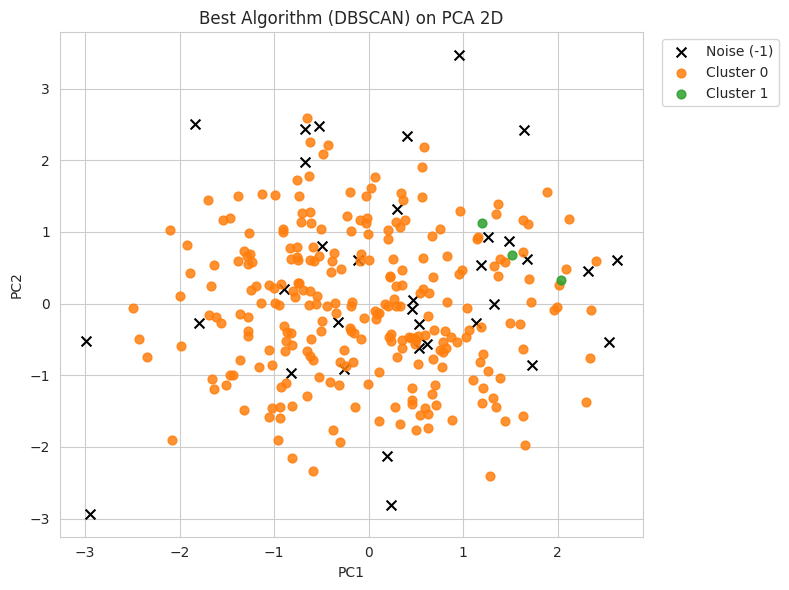

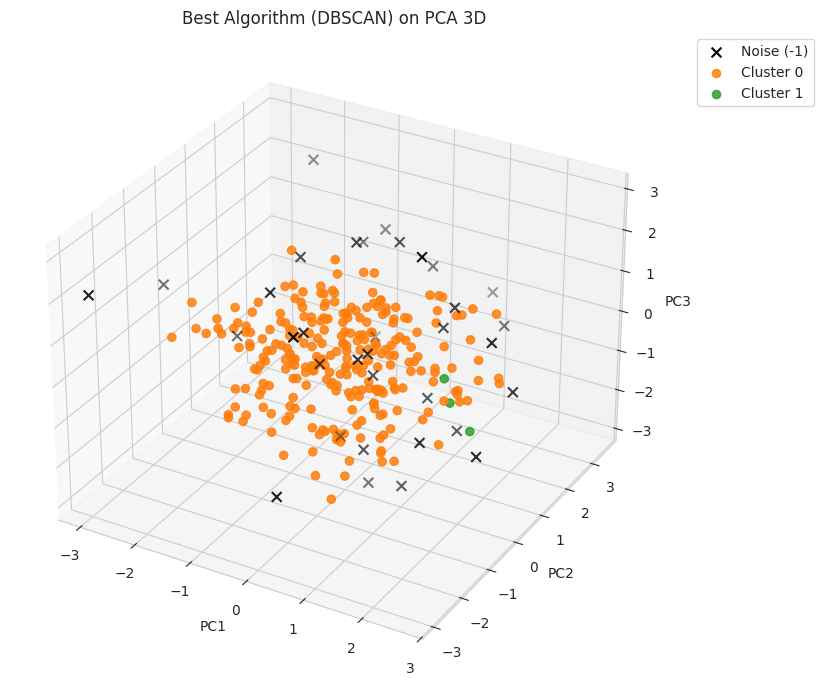

In [25]:
best_labels = labels_store[best_algo]

# PCA 2D and 3D
pca2_final = PCA(n_components=2, random_state=RANDOM_STATE)
X_best_2d = pca2_final.fit_transform(X)

pca3_final = PCA(n_components=3, random_state=RANDOM_STATE)
X_best_3d = pca3_final.fit_transform(X)

print(f'Best algo: {best_algo}')
print(f'PCA 2D explained variance: {pca2_final.explained_variance_ratio_.sum():.3f}')
print(f'PCA 3D explained variance: {pca3_final.explained_variance_ratio_.sum():.3f}')

# 2D plot
plot_clusters_2d(X_best_2d, best_labels, f'Best Algorithm ({best_algo}) on PCA 2D')

# 3D plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

unique_labels = np.unique(best_labels)
colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(unique_labels))))
for i, lab in enumerate(unique_labels):
    mask = best_labels == lab
    if lab == -1:
        ax.scatter(X_best_3d[mask, 0], X_best_3d[mask, 1], X_best_3d[mask, 2], c='black', marker='x', s=50, label='Noise (-1)')
    else:
        ax.scatter(
            X_best_3d[mask, 0], X_best_3d[mask, 1], X_best_3d[mask, 2],
            color=colors[i], s=35, alpha=0.85, label=f'Cluster {lab}'
        )

ax.set_title(f'Best Algorithm ({best_algo}) on PCA 3D')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()